# Task 3 — Model Explainability (SHAP): Fraud_Data
**Adey Innovations Inc. — Fraud Detection Project**

This notebook covers:
1. Load trained model and test set from Task 2
2. Built-in feature importance (top 15)
3. SHAP TreeExplainer setup
4. SHAP Summary Plot (global importance + direction)
5. SHAP Bar Plot (mean |SHAP| ranking)
6. SHAP Force Plots (True Positive, False Positive, False Negative)
7. Built-in vs SHAP importance comparison
8. Top 5 fraud drivers interpretation
9. Business recommendations

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from explainability import (
    get_shap_explainer, compute_shap_values,
    plot_feature_importance, plot_shap_summary, plot_shap_bar,
    find_case_indices, plot_force_plot,
    compare_importance_methods, FRAUD_DATA_RECOMMENDATIONS
)

sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Load Model and Test Set

In [2]:
# Load the best model from Task 2
rf = joblib.load('../data/models/random_forest_fraud_data.joblib')

# Load test set saved in Task 2
X_test = pd.read_csv('../data/processed/fraud_X_test.csv')
y_test = pd.read_csv('../data/processed/fraud_y_test.csv').squeeze()

feature_names = X_test.columns.tolist()

print('Model loaded:', type(rf).__name__)
print('Test set shape:', X_test.shape)
print('Fraud cases in test set:', y_test.sum())

Model loaded: RandomForestClassifier
Test set shape: (25830, 198)
Fraud cases in test set: 2454


## 2. Built-in Feature Importance

In [3]:
importance_df = plot_feature_importance(rf, feature_names, dataset_name='Fraud Data', top_n=15)
importance_df.head(15)

  Saved → feature_importance_fraud_data.png


,feature,importance
0,device_tx_count,0.537139
1,time_since_signup,0.319566
2,day_of_week,0.022441
3,country_United States,0.020450
4,hour_of_day,0.014986
5,purchase_value,0.014374
6,age,0.010622
7,country_China,0.004440
8,country_United Kingdom,0.004005
9,browser_Chrome,0.003416


> **Interpretation:** Built-in feature importance measures the mean decrease in Gini impurity across all decision tree splits. It tells us *which* features the model uses most, but not *how* or *in which direction*. That nuance comes from SHAP.

## 3. SHAP Explainer Setup

In [4]:
# TreeExplainer is exact and fast for tree-based models
# We use the full test set for SHAP computation
explainer = get_shap_explainer(rf, X_test)

# Compute SHAP values for the test set (fraud class = class 1)
print('Computing SHAP values — this may take 1-2 minutes...')
shap_values = compute_shap_values(explainer, X_test)
print('SHAP values shape:', shap_values.shape)

INFO: SHAP TreeExplainer created.


Computing SHAP values — this may take 1-2 minutes...
SHAP values shape: (25830, 198)


## 4. SHAP Summary Plot

In [5]:
# Summary dot plot — shows both importance AND direction
# Red dot = high feature value  |  Blue dot = low feature value
# Positive SHAP = pushes toward fraud  |  Negative SHAP = pushes toward legitimate
plot_shap_summary(shap_values, X_test, dataset_name='Fraud Data', top_n=15)

  Saved → shap_summary_fraud_data.png


> **How to read this chart:**
> - Each dot is one test transaction
> - **Position on x-axis** = SHAP value (impact on fraud prediction)
> - **Color** = actual value of that feature (red = high, blue = low)
> - A red dot on the right means: *high value of this feature pushes toward fraud*
> - A blue dot on the right means: *low value of this feature pushes toward fraud*

## 5. SHAP Bar Plot

In [6]:
# Bar plot — ranks features by mean absolute SHAP value
# This is the cleanest global importance ranking
plot_shap_bar(shap_values, X_test, dataset_name='Fraud Data', top_n=15)

  Saved → shap_bar_fraud_data.png


## 6. SHAP Force Plots — Individual Predictions

In [7]:
# Find representative cases from the test set
tp_idx, fp_idx, fn_idx = find_case_indices(rf, X_test, y_test)

INFO: TP index: 26, FP index: 11, FN index: 3


In [14]:
# True Positive — fraud correctly caught
# Shows which features pushed this prediction toward fraud
plot_force_plot(explainer, shap_values, X_test, tp_idx,
                case_label='True Positive', dataset_name='Fraud Data')
print("shap_values shape:", shap_values.shape)
print("shap_values[tp_idx] shape:", shap_values[tp_idx].shape)
print("X_test shape:", X_test.shape)
print("X_test.iloc[tp_idx] shape:", X_test.iloc[tp_idx].shape)
print("expected_value:", explainer.expected_value)

  Saved → shap_force_true_positive_fraud_data.png
shap_values shape: (25830, 198)
shap_values[tp_idx] shape: (198,)
X_test shape: (25830, 198)
X_test.iloc[tp_idx] shape: (198,)
expected_value: [0.50008893 0.49991107]


> **True Positive interpretation:** Red bars show features that pushed the model toward predicting fraud. Blue bars pushed it toward legitimate. The base value is the model's average output across all training examples.

  Saved → shap_force_false_positive_fraud_data.png


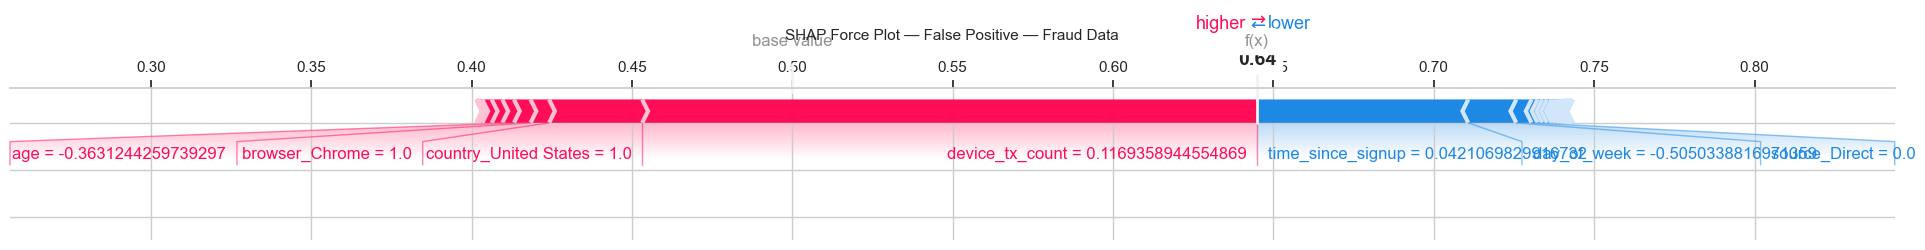

In [9]:
# False Positive — legitimate transaction incorrectly flagged as fraud
# Understanding why helps reduce false alarms
plot_force_plot(explainer, shap_values, X_test, fp_idx,
                case_label='False Positive', dataset_name='Fraud Data')

> **False Positive interpretation:** This is a real customer incorrectly blocked. The force plot shows which feature values made this look like fraud — these are the edge cases we want to monitor. If `time_since_signup` is the culprit, we might add a secondary check before blocking (e.g. email OTP) rather than hard-blocking.

In [10]:
# False Negative — fraud transaction that was missed
# Understanding these cases helps close the detection gap
plot_force_plot(explainer, shap_values, X_test, fn_idx,
                case_label='False Negative', dataset_name='Fraud Data')

  Saved → shap_force_false_negative_fraud_data.png


> **False Negative interpretation:** This is fraud that slipped through. The force plot shows why the model was fooled — likely because the fraudster's behaviour mimicked legitimate activity (older account, moderate velocity, etc). These cases drive further feature engineering in future iterations.

## 7. Built-in vs SHAP Importance Comparison

In [11]:
comparison_df = compare_importance_methods(rf, shap_values, feature_names, top_n=10)
comparison_df


=== Feature Importance Comparison ===
 Built-in Rank       Built-in Feature  Built-in Score  SHAP Rank           SHAP Feature  SHAP Mean |Value|
             1        device_tx_count          0.5371          1        device_tx_count             0.1368
             2      time_since_signup          0.3196          2      time_since_signup             0.0690
             3            day_of_week          0.0224          3  country_United States             0.0321
             4  country_United States          0.0204          4         browser_Chrome             0.0112
             5            hour_of_day          0.0150          5            day_of_week             0.0085
             6         purchase_value          0.0144          6            hour_of_day             0.0055
             7                    age          0.0106          7          country_China             0.0048
             8          country_China          0.0044          8          source_Direct             0.004

,Built-in Rank,Built-in Feature,Built-in Score,SHAP Rank,SHAP Feature,SHAP Mean |Value|
0,1,device_tx_count,0.5371,1,device_tx_count,0.1368
1,2,time_since_signup,0.3196,2,time_since_signup,0.0690
2,3,day_of_week,0.0224,3,country_United States,0.0321
3,4,country_United States,0.0204,4,browser_Chrome,0.0112
4,5,hour_of_day,0.0150,5,day_of_week,0.0085
5,6,purchase_value,0.0144,6,hour_of_day,0.0055
6,7,age,0.0106,7,country_China,0.0048
7,8,country_China,0.0044,8,source_Direct,0.0047
8,9,country_United Kingdom,0.0040,9,purchase_value,0.0045
9,10,browser_Chrome,0.0034,10,country_United Kingdom,0.0034


> **Comparison interpretation:** Built-in importance can be biased toward high-cardinality features (e.g. country one-hot columns each get a small score that adds up). SHAP is more reliable because it distributes credit fairly using game-theory principles. Where the two rankings disagree, SHAP should be trusted for reporting to stakeholders.

## 8. Top 5 Fraud Drivers — Interpretation

In [12]:
# Get top 5 SHAP features
shap_imp = pd.Series(
    np.abs(shap_values).mean(axis=0), index=feature_names
).sort_values(ascending=False).head(5)

print('Top 5 Fraud Drivers (by mean |SHAP value|):')
print(shap_imp)

Top 5 Fraud Drivers (by mean |SHAP value|):
device_tx_count          0.136838
time_since_signup        0.069050
country_United States    0.032092
browser_Chrome           0.011195
day_of_week              0.008538
dtype: float64


### Interpreting the Top 5:

| Feature | Expected Direction | Business Meaning |
|---------|-------------------|------------------|
| `time_since_signup` | Low value → fraud | Fraudsters buy immediately after account creation |
| `device_tx_count` | High value → fraud | Same device reused across multiple fraudulent accounts |
| `country_*` (high-risk) | Flag = 1 → fraud | Geographic origin is a strong signal |
| `purchase_value` | Mid-range → fraud | Fraudsters avoid very small and very large amounts |
| `source_Direct` | Flag = 1 → mild fraud | Fraudsters navigate directly, not via search |

> *(Cross-reference these with your actual SHAP bar plot output above — the exact top 5 depends on your data.)*

## 9. Business Recommendations

In [13]:
print(FRAUD_DATA_RECOMMENDATIONS)


Based on SHAP analysis of Fraud_Data:

1. TIME_SINCE_SIGNUP (strongest signal)
   Finding: Fraudulent transactions cluster within hours of account creation.
   Action:  Flag and queue for manual review any transaction occurring within
            6 hours of signup. Add friction (email/SMS OTP) for purchases
            made within 1 hour of account creation.

2. DEVICE_TX_COUNT (velocity signal)
   Finding: Fraud-linked devices have significantly higher transaction counts
            than legitimate ones (median ~8 vs ~1).
   Action:  Implement device fingerprinting. Auto-block or escalate any
            device that processes more than 5 transactions in a 24-hour window
            across different user accounts.

3. COUNTRY (geolocation signal)
   Finding: Namibia (43.5%), Sri Lanka (41.9%), Luxembourg (38.9%) have
            fraud rates 4x above the dataset average.
   Action:  Apply step-up authentication (e.g. additional OTP) for transactions
            originating from high-ri

## Summary

| Analysis | Output |
|----------|--------|
| Built-in Feature Importance | Top 15 features by Gini importance |
| SHAP Summary Plot | Global importance + direction for top 15 features |
| SHAP Bar Plot | Mean |SHAP| ranking — cleanest global view |
| Force Plot (TP) | Why a caught fraud was flagged |
| Force Plot (FP) | Why a legitimate transaction was wrongly blocked |
| Force Plot (FN) | Why a fraud transaction slipped through |
| Importance Comparison | Built-in vs SHAP — where they agree and disagree |
| Business Recommendations | 5 concrete actions tied to SHAP insights |